In [53]:
!git clone https://github.com/JusticeZzy/FunduSegmenter.git

%cd FunduSegmenter

d:\Projects\College\Rabcl\Segmentation\FunduSegmenter\FunduSegmenter


fatal: destination path 'FunduSegmenter' already exists and is not an empty directory.


In [54]:
!python --version

Python 3.11.5


In [55]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [56]:
import torch
from torch.nn import functional as F

from model.baselines.dunet import DUNet

DUNET_WEIGHTS = r"D:\Projects\College\Rabcl\DUNet_OD_CentreCrop_pretrained.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dunet = DUNet(
    input_channel=3,
    output_channel=2,
    base_channel=32
)

checkpoint = torch.load(
    DUNET_WEIGHTS,
    map_location="cpu",
    weights_only=False
)

dunet.load_state_dict(
    checkpoint["model"],
    strict=True
)

dunet = dunet.to(device)
dunet.eval()

print("✅ DUNet loaded")
print("Device:", device)

✅ DUNet loaded
Device: cuda


In [57]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

manifest = pd.read_csv(
    r"D:\Projects\College\Rabcl\preprocessed.csv"
)

row = manifest.iloc[139]

image_path = os.path.join(
    r"D:\Projects\College\Rabcl\BRSET_processed\train",
    str(int(row["patient_id"])),
    row["exam_eye"] + ".jpg"
)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(image_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(image_path)
print("Image:", row["exam_eye"])
print("Shape:", img_rgb.shape)

D:\Projects\College\Rabcl\BRSET_processed\train\95\left.jpg
Image: left
Shape: (384, 384, 3)


In [58]:
from utils.transform import validation_transform

transform = validation_transform(image_size=256)

transform_image, transform_both = transform

transformed = transform_image(image=img_rgb)
x = transformed["image"]

transformed = transform_both(image=x)
x = transformed["image"]

x = x.unsqueeze(0).to(device)

print("DUNet input:", x.shape)
print("dtype:", x.dtype)

DUNet input: torch.Size([1, 3, 256, 256])
dtype: torch.float32


In [59]:
with torch.no_grad():
    y_pred = dunet(x)

print("Raw DUNet output:", y_pred.shape)

y_pred = F.interpolate(
    y_pred,
    size=(img_rgb.shape[0], img_rgb.shape[1]),
    mode="bicubic"
)

y_pred = torch.argmax(
    torch.softmax(y_pred, dim=1),
    dim=1
)

dunet_mask = y_pred.squeeze().cpu().numpy().astype(np.uint8)

print("DUNet mask:", dunet_mask.shape)
print("Unique values:", np.unique(dunet_mask))

Raw DUNet output: torch.Size([1, 2, 256, 256])
DUNet mask: (384, 384)
Unique values: [0]


In [60]:
min_area_ratio = 0.01
max_area_ratio = 0.30

# Convert to 0/255 exactly as official code
if dunet_mask.max() <= 1:
    dunet_mask = (dunet_mask * 255).astype(np.uint8)

contours, _ = cv2.findContours(
    dunet_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

best_circularity = -1
best_contour = None

H, W = img_rgb.shape[:2]

for contour in contours:

    area = cv2.contourArea(contour)

    area_ratio = area / (H * W)

    if area_ratio < min_area_ratio or area_ratio > max_area_ratio:
        continue

    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        circularity = 0
    else:
        circularity = (
            4 * np.pi * area /
            (perimeter * perimeter)
        )

    if circularity > best_circularity:
        best_circularity = circularity
        best_contour = contour

if best_contour is None:
    print("⚠️ No contour passed area filtering.")
    best_contour = max(contours, key=cv2.contourArea)

(x, y), radius = cv2.minEnclosingCircle(best_contour)

centre = (int(x), int(y))

print("✅ OD centre:", centre)
print("Radius:", radius)
print("Best circularity:", best_circularity)

Number of contours: 0
⚠️ No contour passed area filtering.


ValueError: max() arg is an empty sequence

OD centre: (319, 184)
Square crop: (-416, -416, 384, 384)
Crop size: 800 x 800


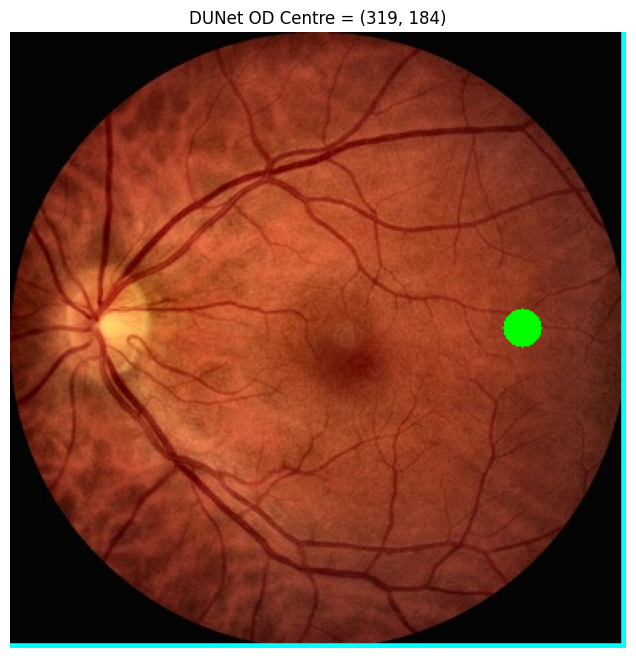

In [61]:
overlay = img_rgb.copy()

# Draw DUNet contour
cv2.drawContours(
    overlay,
    [best_contour],
    -1,
    (255, 0, 0),
    3
)

# Draw centre
cv2.circle(
    overlay,
    centre,
    12,
    (0, 255, 0),
    -1
)

# --------------------------------------------------
# Draw a TRUE 800 x 800 square crop boundary
# while keeping the entire square inside the image
# --------------------------------------------------

cx, cy = centre

crop_size = 800
half = crop_size // 2

img_h, img_w = img_rgb.shape[:2]

# Initial square centered on the detected OD
left = cx - half * 2
top = cy - half
right = left + crop_size
bottom = top + crop_size

# Shift horizontally if the square exceeds image bounds
if left < 0:
    left = 0
    right = crop_size

if right > img_w:
    right = img_w
    left = img_w - crop_size

# Shift vertically if the square exceeds image bounds
if top < 0:
    top = 0
    bottom = crop_size

if bottom > img_h:
    bottom = img_h
    top = img_h - crop_size

# Draw the corrected square
cv2.rectangle(
    overlay,
    (left, top),
    (right - 1, bottom - 1),
    (0, 255, 255),
    3
)

print("OD centre:", (cx, cy))
print("Square crop:", (left, top, right, bottom))
print("Crop size:", right - left, "x", bottom - top)

plt.figure(figsize=(10, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title(f"DUNet OD Centre = ({cx}, {cy})")
plt.show()

In [62]:
# ============================================================
# DUNet OUTPUT -> BINARY OD MASK
# ============================================================

# dunet_mask contains:
#   0 = background
#   1 = OD
#
# Convert directly to:
#   0   = black background
#   255 = white OD

dunet_od_mask = np.where(
    dunet_mask > 0,
    255,
    0
).astype(np.uint8)

print("DUNet OD mask shape:", dunet_od_mask.shape)
print("Unique values:", np.unique(dunet_od_mask))

DUNet OD mask shape: (384, 384)
Unique values: [0]


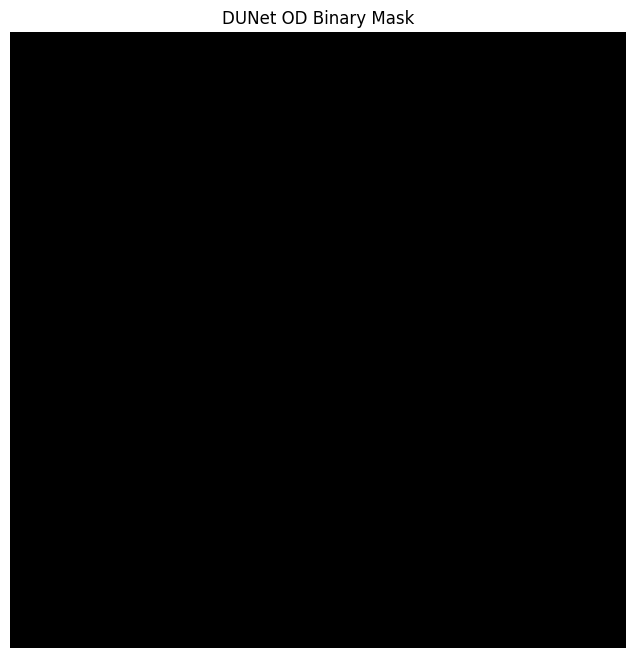

In [63]:
plt.figure(figsize=(8, 8))

plt.imshow(
    dunet_od_mask,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)

plt.title("DUNet OD Binary Mask")
plt.axis("off")

plt.show()

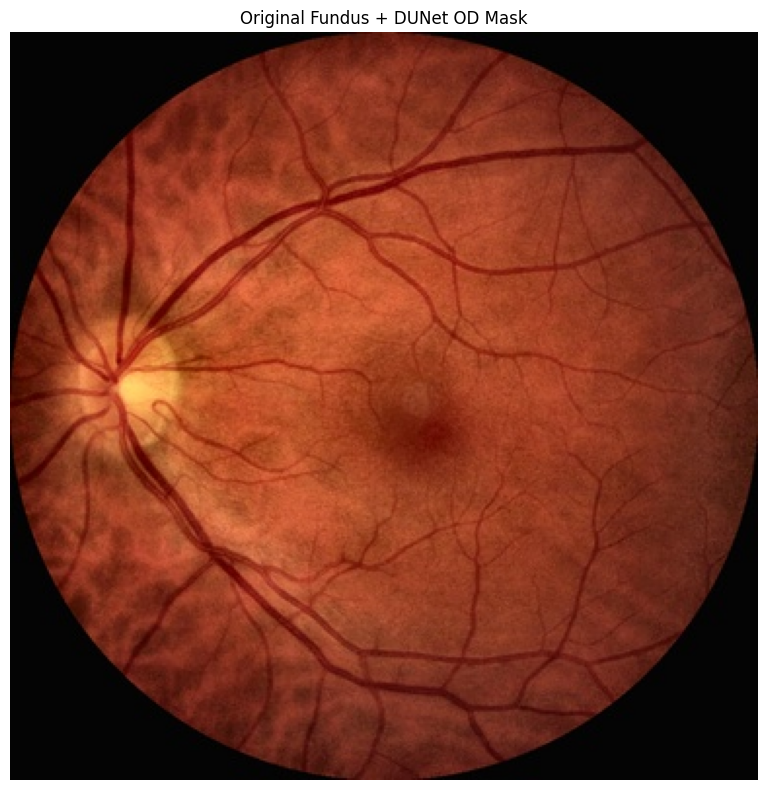

In [64]:
# ============================================================
# DUNet OD MASK OVERLAY ON ORIGINAL FUNDUS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Original fundus as background
ax.imshow(img_rgb)

# Create transparent overlay
overlay = np.zeros(
    (*dunet_od_mask.shape, 4),
    dtype=np.float32
)

# OD pixels
od_pixels = dunet_od_mask == 255

# White OD mask
overlay[od_pixels, 0] = 1.0
overlay[od_pixels, 1] = 1.0
overlay[od_pixels, 2] = 1.0

# Transparency
overlay[od_pixels, 3] = 0.45

# Overlay on original fundus
ax.imshow(overlay)

ax.set_title("Original Fundus + DUNet OD Mask")
ax.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# DELETE EXISTING OD MASKS
# ============================================================

import os

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

removed = 0

for patient_id in os.listdir(MASKS_OUTPUT):

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        patient_id
    )

    if not os.path.isdir(patient_folder):
        continue

    for eye_name in ["Left", "Right"]:

        od_path = os.path.join(
            patient_folder,
            f"{eye_name}_OD.png"
        )

        if os.path.isfile(od_path):

            os.remove(od_path)

            removed += 1

print(
    "Existing OD masks removed:",
    removed
)

Existing OD masks removed: 0


In [81]:
# ============================================================
# GENERATE DUNet OD MASKS FOR ALL BRSET SAMPLES
#
# Masks are saved in:
#
# masks_output/
# ├── 1/
# │   ├── Left_OD.png
# │   └── Right_OD.png
# ├── 2/
# │   ├── Left_OD.png
# │   └── Right_OD.png
# └── ...
#
# Mask:
#   255 = OD (white)
#     0 = background (black)
#
# Mask resolution = input image resolution
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.nn import functional as F
from tqdm.auto import tqdm


# ============================================================
# PATHS
# ============================================================

BRSET_DIR = r"D:\Projects\College\Rabcl\BRSET_processed\train"

MANIFEST_PATH = r"D:\Projects\College\Rabcl\preprocessed.csv"

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"


# ============================================================
# CREATE MASK OUTPUT DIRECTORY
# ============================================================

os.makedirs(
    MASKS_OUTPUT,
    exist_ok=True
)


# ============================================================
# LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

print("Total images:", len(manifest))

print(
    "Total patients:",
    manifest["patient_id"].nunique()
)

print(
    "\nColumns:",
    manifest.columns.tolist()
)


# ============================================================
# DUNet INFERENCE FUNCTION
# ============================================================

def generate_dunet_od_mask(image_rgb):

    # Original image resolution
    original_h, original_w = image_rgb.shape[:2]

    # --------------------------------------------------------
    # DUNet preprocessing
    # Keep DUNet input at 256 × 256
    # --------------------------------------------------------

    transform = validation_transform(
        image_size=256
    )

    transform_image, transform_both = transform

    transformed = transform_image(
        image=image_rgb
    )

    x = transformed["image"]

    transformed = transform_both(
        image=x
    )

    x = transformed["image"]

    x = x.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # DUNet prediction
    # --------------------------------------------------------

    with torch.no_grad():

        y_pred = dunet(x)

    # --------------------------------------------------------
    # Resize prediction back to input image resolution
    # --------------------------------------------------------

    y_pred = F.interpolate(
        y_pred,
        size=(original_h, original_w),
        mode="bicubic"
    )

    # --------------------------------------------------------
    # Convert logits → predicted class
    # --------------------------------------------------------

    y_pred = torch.argmax(
        y_pred,
        dim=1
    )

    dunet_mask = (
        y_pred
        .squeeze()
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    # --------------------------------------------------------
    # Binary OD mask
    #
    # 255 = OD
    #   0 = background
    # --------------------------------------------------------

    od_mask = np.where(
        dunet_mask > 0,
        255,
        0
    ).astype(np.uint8)

    # ------------------------------------------------------------
    # KEEP ONLY THE LARGEST OD COMPONENT
    # ------------------------------------------------------------

    binary_mask = (
        od_mask > 0
    ).astype(np.uint8)

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    if num_labels > 1:

        # Ignore background (label 0)
        largest_label = (
            1
            + np.argmax(
                stats[1:, cv2.CC_STAT_AREA]
            )
        )

        od_mask = np.where(
            labels == largest_label,
            255,
            0
        ).astype(np.uint8)

    else:

        # No OD prediction
        od_mask = np.zeros_like(
            od_mask,
            dtype=np.uint8
        )

    return od_mask


# ============================================================
# PROCESS ALL BRSET IMAGES
# ============================================================

success = 0
skipped = 0
failed = 0

for _, row in tqdm(
    manifest.iterrows(),
    total=len(manifest),
    desc="Generating DUNet OD masks"
):

    try:

        # ----------------------------------------------------
        # Patient ID
        # ----------------------------------------------------

        patient_id = int(
            row["patient_id"]
        )

        # ----------------------------------------------------
        # Eye
        # ----------------------------------------------------

        eye = str(
            row["exam_eye"]
        ).strip().lower()

        if eye == "left":

            eye_name = "Left"

        elif eye == "right":

            eye_name = "Right"

        else:

            print(
                f"\n⚠️ Unknown eye label:"
                f" {row['exam_eye']}"
            )

            failed += 1
            continue

        # ----------------------------------------------------
        # INPUT PATIENT FOLDER
        # ----------------------------------------------------

        patient_folder = os.path.join(
            BRSET_DIR,
            str(patient_id)
        )

        # ----------------------------------------------------
        # INPUT IMAGE
        # ----------------------------------------------------

        image_path = os.path.join(
            patient_folder,
            eye + ".jpg"
        )

        # ----------------------------------------------------
        # OUTPUT PATIENT FOLDER
        #
        # masks_output/
        # └── 1/
        #     ├── Left_OD.png
        #     └── Right_OD.png
        # ----------------------------------------------------

        mask_patient_folder = os.path.join(
            MASKS_OUTPUT,
            str(patient_id)
        )

        os.makedirs(
            mask_patient_folder,
            exist_ok=True
        )

        # ----------------------------------------------------
        # OUTPUT MASK PATH
        # ----------------------------------------------------

        output_path = os.path.join(
            mask_patient_folder,
            f"{eye_name}_OD.png"
        )

        # ----------------------------------------------------
        # If mask already exists → skip
        # ----------------------------------------------------

        if os.path.isfile(output_path):

            skipped += 1
            continue

        # ----------------------------------------------------
        # Read image
        # ----------------------------------------------------

        img_bgr = cv2.imread(
            image_path
        )

        if img_bgr is None:

            print(
                f"\n❌ Could not read:"
                f" {image_path}"
            )

            failed += 1
            continue

        # ----------------------------------------------------
        # BGR → RGB
        # ----------------------------------------------------

        img_rgb = cv2.cvtColor(
            img_bgr,
            cv2.COLOR_BGR2RGB
        )

        # ----------------------------------------------------
        # Generate OD mask
        # ----------------------------------------------------

        od_mask = generate_dunet_od_mask(
            img_rgb
        )

        # ----------------------------------------------------
        # Save mask
        # ----------------------------------------------------

        success_write = cv2.imwrite(
            output_path,
            od_mask
        )

        if not success_write:

            print(
                f"\n❌ Could not save:"
                f" {output_path}"
            )

            failed += 1
            continue

        success += 1

    except Exception as e:

        print(
            f"\n❌ Failed:"
            f" patient_{patient_id:05d}"
        )

        print(
            "Image:",
            image_path
        )

        print(
            "Error:",
            e
        )

        failed += 1


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("DUNet OD MASK GENERATION COMPLETE")
print("=" * 60)

print(
    "New masks generated:",
    success
)

print(
    "Already existed:",
    skipped
)

print(
    "Failed:",
    failed
)

print(
    "Total manifest rows:",
    len(manifest)
)

print()

print(
    "Masks saved in:"
)

print(
    MASKS_OUTPUT
)

Total images: 12164
Total patients: 6082

Columns: ['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


Generating DUNet OD masks: 100%|██████████| 12164/12164 [07:44<00:00, 26.20it/s]



DUNet OD MASK GENERATION COMPLETE
New masks generated: 12164
Already existed: 0
Failed: 0
Total manifest rows: 12164

Masks saved in:
D:\Projects\College\Rabcl\masks_output


In [82]:
def is_valid_od_mask(mask_path):

    # --------------------------------------------------------
    # File must exist
    # --------------------------------------------------------

    if not os.path.isfile(mask_path):
        return False, "OD mask missing"


    # --------------------------------------------------------
    # Read mask
    # --------------------------------------------------------

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        return False, "Could not read OD mask"


    # --------------------------------------------------------
    # Check unique values
    # --------------------------------------------------------

    unique_values = np.unique(mask)

    if len(unique_values) <= 1:
        return False, (
            f"No foreground pixels; "
            f"unique values = {unique_values.tolist()}"
        )


    # --------------------------------------------------------
    # Binary foreground
    # --------------------------------------------------------

    foreground = (
        mask > 0
    ).astype(np.uint8)


    if np.sum(foreground) == 0:
        return False, "No foreground pixels"


    # --------------------------------------------------------
    # Find separate OD spots
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        foreground,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    if len(contours) == 0:
        return False, "No contour found"


    # --------------------------------------------------------
    # Check for multiple separate regions
    # --------------------------------------------------------

    if len(contours) > 1:

        return False, (
            f"Multiple OD spots detected: "
            f"{len(contours)} contours"
        )


    # --------------------------------------------------------
    # Check contour area
    # --------------------------------------------------------

    largest_area = cv2.contourArea(
        contours[0]
    )


    if largest_area <= 0:
        return False, "Contour area is zero"


    # --------------------------------------------------------
    # Valid
    # --------------------------------------------------------

    return True, "Valid"

In [83]:
# ============================================================
# CHECK EVERY PATIENT
# ============================================================

from tqdm.auto import tqdm

invalid_patients = []
invalid_details = []

total_patients = manifest["patient_id"].nunique()

print()
print("=" * 60)
print("STARTING OD MASK VALIDATION")
print("=" * 60)
print(
    f"Checking {total_patients} patients "
    f"({total_patients * 2} OD masks)"
)
print()


for patient_id in tqdm(
    sorted(manifest["patient_id"].unique()),
    total=total_patients,
    desc="Checking OD masks",
    unit="patient"
):

    patient_id = int(patient_id)

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        str(patient_id)
    )

    patient_invalid = False


    # --------------------------------------------------------
    # Check BOTH eyes
    # --------------------------------------------------------

    for eye_name in ["Left", "Right"]:

        od_path = os.path.join(
            patient_folder,
            f"{eye_name}_OD.png"
        )

        valid, reason = is_valid_od_mask(
            od_path
        )

        if not valid:

            patient_invalid = True

            invalid_details.append({

                "patient_id": patient_id,

                "eye": eye_name,

                "reason": reason,

                "path": od_path

            })


    # --------------------------------------------------------
    # If either eye is invalid,
    # mark entire patient as invalid
    # --------------------------------------------------------

    if patient_invalid:

        invalid_patients.append(
            patient_id
        )


# ============================================================
# SUMMARY
# ============================================================

invalid_patients = sorted(
    set(invalid_patients)
)

valid_patients = (
    total_patients
    - len(invalid_patients)
)


print("\n")
print("=" * 60)
print("OD MASK VALIDATION COMPLETE")
print("=" * 60)

print(
    "Total patients checked:",
    total_patients
)

print(
    "Valid patients:",
    valid_patients
)

print(
    "Invalid patients:",
    len(invalid_patients)
)

print()

print(
    "Invalid patient IDs:"
)

print(
    invalid_patients
)

print("\n")
print("Invalid mask details:")

for item in invalid_details:

    print(
        f"Patient {item['patient_id']} - "
        f"{item['eye']} : "
        f"{item['reason']}"
    )


STARTING OD MASK VALIDATION
Checking 6082 patients (12164 OD masks)



Checking OD masks: 100%|██████████| 6082/6082 [02:49<00:00, 35.95patient/s]



OD MASK VALIDATION COMPLETE
Total patients checked: 6082
Valid patients: 5650
Invalid patients: 432

Invalid patient IDs:
[95, 174, 238, 265, 282, 294, 349, 379, 386, 395, 423, 434, 532, 540, 549, 575, 589, 621, 627, 635, 637, 647, 715, 720, 723, 729, 808, 833, 844, 847, 881, 888, 893, 932, 935, 948, 964, 965, 980, 990, 1000, 1013, 1016, 1025, 1059, 1068, 1092, 1125, 1132, 1133, 1139, 1153, 1182, 1188, 1191, 1248, 1254, 1277, 1289, 1297, 1351, 1361, 1368, 1382, 1389, 1390, 1392, 1442, 1446, 1454, 1487, 1498, 1533, 1535, 1580, 1613, 1625, 1664, 1670, 1674, 1683, 1695, 1701, 1726, 1798, 1819, 1851, 1857, 1867, 1876, 1893, 1900, 1909, 1938, 1954, 1968, 1999, 2048, 2062, 2074, 2102, 2124, 2142, 2155, 2159, 2169, 2186, 2196, 2206, 2231, 2232, 2264, 2368, 2382, 2384, 2401, 2420, 2438, 2447, 2504, 2543, 2561, 2591, 2609, 2626, 2629, 2668, 2700, 2734, 2744, 2750, 2760, 2775, 2849, 2861, 2865, 2871, 2938, 2939, 2948, 2963, 3015, 3041, 3048, 3053, 3085, 3112, 3118, 3141, 3146, 3165, 3168, 3174

In [85]:
import os
import shutil
import pandas as pd

MANIFEST_PATH = r"D:\Projects\College\Rabcl\preprocessed.csv"
MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

BACKUP_PATH = r"D:\Projects\College\Rabcl\preprocessed_backup.csv"

shutil.copy2(
    MANIFEST_PATH,
    BACKUP_PATH
)

print("Backup created:")
print(BACKUP_PATH)

Backup created:
D:\Projects\College\Rabcl\preprocessed_backup.csv


In [86]:
# ============================================================
# REMOVE INVALID PATIENTS FROM preprocessed.csv
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

print("Rows before:", len(manifest))
print(
    "Patients before:",
    manifest["patient_id"].nunique()
)

# Make sure IDs have the same type
manifest["patient_id"] = manifest["patient_id"].astype(int)

# Remove every row belonging to an invalid patient
manifest_clean = manifest[
    ~manifest["patient_id"].isin(
        invalid_patients
    )
].copy()

print()
print("Rows after:", len(manifest_clean))
print(
    "Patients after:",
    manifest_clean["patient_id"].nunique()
)

print(
    "Patients removed:",
    len(invalid_patients)
)

Rows before: 12164
Patients before: 6082

Rows after: 11300
Patients after: 5650
Patients removed: 432


In [87]:
manifest_clean.to_csv(
    MANIFEST_PATH,
    index=False
)

print()
print("✅ Cleaned preprocessed.csv saved.")
print(MANIFEST_PATH)


✅ Cleaned preprocessed.csv saved.
D:\Projects\College\Rabcl\preprocessed.csv


In [88]:
# ============================================================
# REMOVE INVALID PATIENT FOLDERS FROM masks_output
# ============================================================

import shutil
import os

removed_folders = 0
missing_folders = 0

for patient_id in invalid_patients:

    patient_id = int(patient_id)

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        str(patient_id)
    )

    if os.path.isdir(patient_folder):

        shutil.rmtree(
            patient_folder
        )

        removed_folders += 1

    else:

        missing_folders += 1

print()
print("=" * 60)
print("MASK FOLDER CLEANUP COMPLETE")
print("=" * 60)

print(
    "Patient folders removed:",
    removed_folders
)

print(
    "Patient folders not found:",
    missing_folders
)


MASK FOLDER CLEANUP COMPLETE
Patient folders removed: 432
Patient folders not found: 0


In [67]:
# ============================================================
# OD DUNet - TEST TIME AUGMENTATION (TTA)
# CONSISTENCY / REPRODUCIBILITY EVALUATION
# ============================================================

def tta_images_od(img_rgb):

    images = {}

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    images["original"] = img_rgb.copy()

    # --------------------------------------------------------
    # Brightness increase
    # --------------------------------------------------------

    brighter = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.0,
        beta=15
    )

    images["brightness_up"] = brighter

    # --------------------------------------------------------
    # Brightness decrease
    # --------------------------------------------------------

    darker = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.0,
        beta=-15
    )

    images["brightness_down"] = darker

    # --------------------------------------------------------
    # Mild contrast increase
    # --------------------------------------------------------

    contrast = cv2.convertScaleAbs(
        img_rgb,
        alpha=1.10,
        beta=0
    )

    images["contrast"] = contrast

    # --------------------------------------------------------
    # Mild Gaussian noise
    # --------------------------------------------------------

    noise = np.random.normal(
        0,
        5,
        img_rgb.shape
    )

    noisy = np.clip(
        img_rgb.astype(np.float32) + noise,
        0,
        255
    ).astype(np.uint8)

    images["noise"] = noisy

    return images

In [68]:
# ============================================================
# DUNet OD PREDICTION FUNCTION
# ============================================================

def predict_dunet_od_mask(image_rgb):

    original_h, original_w = image_rgb.shape[:2]

    # --------------------------------------------------------
    # Same preprocessing as existing DUNet pipeline
    # --------------------------------------------------------

    transform = validation_transform(
        image_size=256
    )

    transform_image, transform_both = transform

    transformed = transform_image(
        image=image_rgb
    )

    x = transformed["image"]

    transformed = transform_both(
        image=x
    )

    x = transformed["image"]

    x = x.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # DUNet inference
    # --------------------------------------------------------

    with torch.no_grad():

        y_pred = dunet(x)

    # --------------------------------------------------------
    # Restore original resolution
    # --------------------------------------------------------

    y_pred = F.interpolate(
        y_pred,
        size=(original_h, original_w),
        mode="bicubic"
    )

    # --------------------------------------------------------
    # Convert logits -> class
    # --------------------------------------------------------

    y_pred = torch.argmax(
        torch.softmax(y_pred, dim=1),
        dim=1
    )

    mask = (
        y_pred
        .squeeze()
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    # --------------------------------------------------------
    # Convert to binary OD mask
    #
    # 0   = background
    # 255 = OD
    # --------------------------------------------------------

    od_mask = np.where(
        mask > 0,
        255,
        0
    ).astype(np.uint8)

    return od_mask

In [69]:
# ============================================================
# TTA CONSISTENCY METRICS
# ============================================================

def dice_score(mask_a, mask_b):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    denominator = (
        mask_a.sum() +
        mask_b.sum()
    )

    if denominator == 0:
        return 1.0

    return (
        2.0 * intersection /
        denominator
    )


def iou_score(mask_a, mask_b):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    union = np.logical_or(
        mask_a,
        mask_b
    ).sum()

    if union == 0:
        return 1.0

    return intersection / union

In [70]:
# ============================================================
# SINGLE IMAGE TTA TEST
# ============================================================

tta = tta_images_od(img_rgb)

tta_masks = {}

for name, transformed_img in tta.items():

    tta_masks[name] = predict_dunet_od_mask(
        transformed_img
    )

print("TTA predictions generated:")
print(list(tta_masks.keys()))

TTA predictions generated:
['original', 'brightness_up', 'brightness_down', 'contrast', 'noise']


In [71]:
# ============================================================
# PAIRWISE TTA CONSISTENCY
# ============================================================

names = list(tta_masks.keys())

dice_values = []
iou_values = []

for i in range(len(names)):

    for j in range(i + 1, len(names)):

        a = tta_masks[names[i]]
        b = tta_masks[names[j]]

        dice = dice_score(a, b)
        iou = iou_score(a, b)

        dice_values.append(dice)
        iou_values.append(iou)

        print(
            f"{names[i]:18s} vs "
            f"{names[j]:18s} | "
            f"Dice = {dice:.4f} | "
            f"IoU = {iou:.4f}"
        )

print("\nMean TTA Dice:", np.mean(dice_values))
print("Mean TTA IoU :", np.mean(iou_values))
print("Min TTA Dice :", np.min(dice_values))
print("Min TTA IoU  :", np.min(iou_values))

original           vs brightness_up      | Dice = 0.0000 | IoU = 0.0000
original           vs brightness_down    | Dice = 0.0000 | IoU = 0.0000
original           vs contrast           | Dice = 0.0000 | IoU = 0.0000
original           vs noise              | Dice = 1.0000 | IoU = 1.0000
brightness_up      vs brightness_down    | Dice = 0.4895 | IoU = 0.3241
brightness_up      vs contrast           | Dice = 0.9400 | IoU = 0.8868
brightness_up      vs noise              | Dice = 0.0000 | IoU = 0.0000
brightness_down    vs contrast           | Dice = 0.4397 | IoU = 0.2818
brightness_down    vs noise              | Dice = 0.0000 | IoU = 0.0000
contrast           vs noise              | Dice = 0.0000 | IoU = 0.0000

Mean TTA Dice: 0.28692268015672273
Mean TTA IoU : 0.24926847087224444
Min TTA Dice : 0.0
Min TTA IoU  : 0.0


In [72]:
# ============================================================
# OD AREA STABILITY
# ============================================================

def mask_area(mask):

    return np.sum(mask > 0)


areas = {}

for name, mask in tta_masks.items():

    areas[name] = mask_area(mask)

print("\nOD areas:")

for name, area in areas.items():

    print(
        f"{name:18s}: {area:,} pixels"
    )


area_values = np.array(
    list(areas.values()),
    dtype=np.float64
)

mean_area = np.mean(area_values)
std_area = np.std(area_values)

area_cv = (
    std_area / mean_area
    if mean_area > 0
    else 0
)

print("\nMean OD area:", mean_area)
print("Std OD area :", std_area)
print("Area CV     :", area_cv)


OD areas:
original          : 0 pixels
brightness_up     : 51 pixels
brightness_down   : 92 pixels
contrast          : 49 pixels
noise             : 0 pixels

Mean OD area: 38.4
Std OD area : 34.909024621149186
Area CV     : 0.9090891828424268


In [73]:
# ============================================================
# OD CENTROID
# ============================================================

def get_mask_centroid(mask):

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    return (
        float(np.mean(xs)),
        float(np.mean(ys))
    )


centroids = {}

for name, mask in tta_masks.items():

    centroids[name] = get_mask_centroid(mask)

print("\nOD centroids:")

for name, centroid in centroids.items():

    print(
        f"{name:18s}: {centroid}"
    )


OD centroids:
original          : None
brightness_up     : (79.45098039215686, 175.88235294117646)
brightness_down   : (73.5, 164.90217391304347)
contrast          : (80.0, 177.3877551020408)
noise             : None


In [74]:
# ============================================================
# CENTROID DISPLACEMENT
# ============================================================

original_centroid = centroids["original"]

centroid_displacements = {}

if original_centroid is not None:

    ox, oy = original_centroid

    for name, centroid in centroids.items():

        if centroid is None:

            centroid_displacements[name] = np.nan
            continue

        cx, cy = centroid

        distance = np.sqrt(
            (cx - ox) ** 2 +
            (cy - oy) ** 2
        )

        centroid_displacements[name] = distance

print("\nCentroid displacement from original:")

for name, distance in centroid_displacements.items():

    print(
        f"{name:18s}: {distance:.2f} pixels"
    )


Centroid displacement from original:


In [75]:
# ============================================================
# TTA EVALUATION - ALL BRSET IMAGES
# ============================================================

tta_results = []

test_manifest = manifest.head(20)

for _, row in tqdm(
    test_manifest.iterrows(),
    total=len(test_manifest),
    desc="Running OD TTA evaluation"
):

    patient_id = int(row["patient_id"])
    eye = str(row["exam_eye"]).strip().lower()

    image_path = os.path.join(
        BRSET_DIR,
        str(patient_id),
        eye + ".jpg"
    )

    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        continue

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Generate TTA images
    # --------------------------------------------------------

    tta = tta_images_od(img_rgb)

    # --------------------------------------------------------
    # Generate OD masks
    # --------------------------------------------------------

    tta_masks = {}

    for name, transformed_img in tta.items():

        tta_masks[name] = predict_dunet_od_mask(
            transformed_img
        )

    # --------------------------------------------------------
    # Pairwise Dice / IoU
    # --------------------------------------------------------

    names = list(tta_masks.keys())

    dice_values = []
    iou_values = []

    for i in range(len(names)):

        for j in range(i + 1, len(names)):

            dice_values.append(
                dice_score(
                    tta_masks[names[i]],
                    tta_masks[names[j]]
                )
            )

            iou_values.append(
                iou_score(
                    tta_masks[names[i]],
                    tta_masks[names[j]]
                )
            )

    # --------------------------------------------------------
    # Area stability
    # --------------------------------------------------------

    areas = [
        mask_area(mask)
        for mask in tta_masks.values()
    ]

    mean_area = np.mean(areas)
    std_area = np.std(areas)

    area_cv = (
        std_area / mean_area
        if mean_area > 0
        else 0
    )

    # --------------------------------------------------------
    # Centroid stability
    # --------------------------------------------------------

    centroids = [
        get_mask_centroid(mask)
        for mask in tta_masks.values()
    ]

    original_centroid = centroids[0]

    centroid_distances = []

    if original_centroid is not None:

        ox, oy = original_centroid

        for centroid in centroids[1:]:

            if centroid is None:
                continue

            cx, cy = centroid

            distance = np.sqrt(
                (cx - ox) ** 2 +
                (cy - oy) ** 2
            )

            centroid_distances.append(distance)

    mean_centroid_shift = (
        np.mean(centroid_distances)
        if centroid_distances
        else np.nan
    )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    tta_results.append({

        "patient_id": patient_id,
        "eye": eye,

        "mean_tta_dice":
            np.mean(dice_values),

        "min_tta_dice":
            np.min(dice_values),

        "mean_tta_iou":
            np.mean(iou_values),

        "min_tta_iou":
            np.min(iou_values),

        "mean_od_area":
            mean_area,

        "std_od_area":
            std_area,

        "area_cv":
            area_cv,

        "mean_centroid_shift_px":
            mean_centroid_shift
    })


tta_results = pd.DataFrame(
    tta_results
)

display(tta_results)

Running OD TTA evaluation: 100%|██████████| 20/20 [00:05<00:00,  3.65it/s]


,patient_id,eye,mean_tta_dice,min_tta_dice,mean_tta_iou,min_tta_iou,mean_od_area,std_od_area,area_cv,mean_centroid_shift_px
0,1,right,0.996193,0.992186,0.992422,0.984494,3652.0,5.966574,0.001634,0.105950
1,1,left,0.997507,0.996209,0.995027,0.992446,4090.8,6.431174,0.001572,0.047645
2,2,right,0.993731,0.988276,0.987562,0.976823,3772.2,28.680307,0.007603,0.159947
3,2,left,0.991716,0.984590,0.983594,0.969647,3580.6,19.955951,0.005573,0.905963
4,3,right,0.990978,0.984393,0.982167,0.969266,3055.6,30.414470,0.009954,0.150421
5,3,left,0.993944,0.991861,0.987964,0.983854,2757.0,10.825895,0.003927,0.171333
6,4,right,0.999023,0.998132,0.998049,0.996272,3480.4,1.356466,0.000390,0.025843
7,4,left,0.997665,0.995910,0.995343,0.991853,3296.0,8.740709,0.002652,0.071358
8,5,right,0.996004,0.993938,0.992045,0.987948,3303.8,5.306600,0.001606,0.147610
9,5,left,0.997303,0.994788,0.994622,0.989631,3262.6,7.337575,0.002249,0.081632


In [76]:
tta_results.describe()

,patient_id,mean_tta_dice,min_tta_dice,mean_tta_iou,min_tta_iou,mean_od_area,std_od_area,area_cv,mean_centroid_shift_px
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,5.70000,0.993688,0.988590,0.987520,0.977571,3199.920000,15.900243,0.005089,0.212033
std,3.24605,0.004352,0.008548,0.008515,0.016543,411.984616,11.634715,0.003856,0.223586
min,1.00000,0.983811,0.968772,0.968291,0.939435,2681.600000,1.356466,0.000390,0.025843
25%,3.00000,0.991589,0.984568,0.983351,0.969604,2822.500000,6.773546,0.002095,0.085670
50%,5.50000,0.994959,0.991437,0.989981,0.983020,3159.100000,11.556236,0.004144,0.137989
75%,8.00000,0.997082,0.994818,0.994183,0.989689,3547.250000,22.137040,0.006996,0.173347
max,11.00000,0.999023,0.998132,0.998049,0.996272,4090.800000,39.706926,0.013614,0.905963


In [93]:
# ============================================================
# GENERATE MACULA ROI MASKS FROM DUNet OD MASKS
#
# Output saved next to each patient image folder:
#
# BRSET_processed/train/
# ├── 1/
# │   ├── Left_OD.png
# │   ├── Right_OD.png
# │   ├── Left_macula.png
# │   └── Right_macula.png
# └── ...
#
# Macula mask:
#   255 = macula ROI
#     0 = background
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# ============================================================
# PATHS
# ============================================================

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"
BRSET_DIR = r"D:\Projects\College\Rabcl\BRSET_processed\train"
MANIFEST_PATH = r"D:\Projects\College\Rabcl\preprocessed.csv"


# ============================================================
# LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(MANIFEST_PATH)


# ============================================================
# MACULA ROI PARAMETERS
# ============================================================

# Distance from OD center expressed in OD diameters.
# This is a heuristic anatomical estimate.
MACULA_DISTANCE_OD_DIAMETERS = 2.5

# Radius of the macula ROI expressed in OD diameters.
# This defines the region used for later feature pooling.
MACULA_RADIUS_OD_DIAMETERS = 1.0


# ============================================================
# FIND OD CENTROID AND DIAMETER
# ============================================================

def get_od_geometry(od_mask):

    ys, xs = np.where(od_mask > 0)

    if len(xs) == 0:
        return None

    center_x = float(np.mean(xs))
    center_y = float(np.mean(ys))

    # Use the equivalent circular diameter based on the OD mask area.
    area = len(xs)
    radius = np.sqrt(area / np.pi)
    diameter = 2.0 * radius

    return (center_x, center_y, diameter)


# ============================================================
# GENERATE MACULA MASK
# ============================================================

def generate_macula_mask(od_mask, eye):

    geometry = get_od_geometry(od_mask)

    if geometry is None:
        return None

    disc_x, disc_y, disc_diameter = geometry

    # --------------------------------------------------------
    # Estimate macula center
    # --------------------------------------------------------
    distance = MACULA_DISTANCE_OD_DIAMETERS * disc_diameter

    # Temporal direction:
    # Left eye  -> macula is to the LEFT of the disc
    # Right eye -> macula is to the RIGHT of the disc
    if eye == "left":
        macula_x = disc_x - distance
    elif eye == "right":
        macula_x = disc_x + distance
    else:
        return None

    # Keep the macula approximately at the same vertical position.
    macula_y = disc_y

    # --------------------------------------------------------
    # ROI radius
    # --------------------------------------------------------
    roi_radius = MACULA_RADIUS_OD_DIAMETERS * disc_diameter

    # --------------------------------------------------------
    # Create binary mask
    # --------------------------------------------------------
    macula_mask = np.zeros_like(od_mask, dtype=np.uint8)

    cv2.circle(
        macula_mask,
        (int(round(macula_x)), int(round(macula_y))),
        int(round(roi_radius)),
        255,
        thickness=-1
    )

    return macula_mask


# ============================================================
# PROCESS ALL IMAGES AND SAVE MACULA MASKS IN THE PATIENT FOLDER
# ============================================================

success = 0
skipped = 0
failed = 0

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Generating macula ROI masks"):

    try:
        patient_id = int(row["patient_id"])
        eye = str(row["exam_eye"]).strip().lower()

        if eye == "left":
            eye_name = "Left"
        elif eye == "right":
            eye_name = "Right"
        else:
            failed += 1
            continue

        # Patient folder inside BRSET_processed/train
        patient_folder = os.path.join(BRSET_DIR, str(patient_id))
        os.makedirs(patient_folder, exist_ok=True)

        # OD mask comes from the dedicated masks_output folder
        od_path = os.path.join(MASKS_OUTPUT, str(patient_id), f"{eye_name}_OD.png")
        macula_path = os.path.join(patient_folder, f"{eye_name}_macula.png")

        # Skip if already generated
        if os.path.isfile(macula_path):
            skipped += 1
            continue

        if not os.path.isfile(od_path):
            print(f"\n❌ OD mask missing: {od_path}")
            failed += 1
            continue

        od_mask = cv2.imread(od_path, cv2.IMREAD_GRAYSCALE)

        if od_mask is None:
            print(f"\n❌ Could not read: {od_path}")
            failed += 1
            continue

        macula_mask = generate_macula_mask(od_mask, eye)

        if macula_mask is None:
            print(f"\n❌ Could not generate macula: patient {patient_id}, {eye}")
            failed += 1
            continue

        ys, xs = np.where(macula_mask > 0)

        if len(xs) == 0:
            print(f"\n❌ Empty macula ROI: patient {patient_id}, {eye}")
            failed += 1
            continue

        # --------------------------------------------------------
        # Save the macula mask beside the image in BRSET_processed/train
        # Example:
        # BRSET_processed/train/1/Left_macula.png
        # BRSET_processed/train/1/Right_macula.png
        # --------------------------------------------------------
        success_write = cv2.imwrite(macula_path, macula_mask)

        if not success_write:
            print(f"\n❌ Could not save: {macula_path}")
            failed += 1
            continue

        success += 1

    except Exception as e:
        print(f"\n❌ Failed: patient {patient_id}")
        print("Error:", e)
        failed += 1


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("MACULA ROI GENERATION COMPLETE")
print("=" * 60)
print("New masks generated:", success)
print("Already existed:", skipped)
print("Failed:", failed)
print("Total manifest rows:", len(manifest))
print("\nOutput folder:", BRSET_DIR)


Generating macula ROI masks:   9%|▉         | 1014/11300 [00:00<00:04, 2438.90it/s]


❌ Empty macula ROI: patient 813, left

❌ Empty macula ROI: patient 813, right

❌ Empty macula ROI: patient 814, right

❌ Empty macula ROI: patient 814, left

❌ Empty macula ROI: patient 815, right

❌ Empty macula ROI: patient 815, left

❌ Empty macula ROI: patient 817, right

❌ Empty macula ROI: patient 817, left

❌ Empty macula ROI: patient 818, left

❌ Empty macula ROI: patient 818, right

❌ Empty macula ROI: patient 819, right

❌ Empty macula ROI: patient 820, right

❌ Empty macula ROI: patient 821, left

❌ Empty macula ROI: patient 821, right

❌ Empty macula ROI: patient 822, right

❌ Empty macula ROI: patient 822, left

❌ Empty macula ROI: patient 823, right

❌ Empty macula ROI: patient 823, left

❌ Empty macula ROI: patient 824, right

❌ Empty macula ROI: patient 826, left

❌ Empty macula ROI: patient 826, right

❌ Empty macula ROI: patient 827, left

❌ Empty macula ROI: patient 827, right

❌ Empty macula ROI: patient 828, left

❌ Empty macula ROI: patient 828, right

❌ Empty ma

Generating macula ROI masks:  11%|█         | 1258/11300 [00:00<00:09, 1086.10it/s]


❌ Empty macula ROI: patient 944, left

❌ Empty macula ROI: patient 951, left

❌ Empty macula ROI: patient 951, right

❌ Empty macula ROI: patient 952, right

❌ Empty macula ROI: patient 952, left

❌ Empty macula ROI: patient 953, right

❌ Empty macula ROI: patient 954, right

❌ Empty macula ROI: patient 954, left

❌ Empty macula ROI: patient 957, right

❌ Empty macula ROI: patient 957, left

❌ Empty macula ROI: patient 959, right

❌ Empty macula ROI: patient 960, right

❌ Empty macula ROI: patient 960, left

❌ Empty macula ROI: patient 963, right

❌ Empty macula ROI: patient 967, right

❌ Empty macula ROI: patient 967, left

❌ Empty macula ROI: patient 968, right

❌ Empty macula ROI: patient 968, left

❌ Empty macula ROI: patient 969, right

❌ Empty macula ROI: patient 969, left

❌ Empty macula ROI: patient 970, right

❌ Empty macula ROI: patient 970, left

❌ Empty macula ROI: patient 973, right

❌ Empty macula ROI: patient 973, left

❌ Empty macula ROI: patient 974, right

❌ Empty ma

Generating macula ROI masks:  13%|█▎        | 1434/11300 [00:01<00:12, 786.56it/s] 

...


❌ Empty macula ROI: patient 8410, left

❌ Empty macula ROI: patient 8411, right

❌ Empty macula ROI: patient 8414, right

❌ Empty macula ROI: patient 8414, left

❌ Empty macula ROI: patient 8419, right

❌ Empty macula ROI: patient 8420, left

❌ Empty macula ROI: patient 8422, right

❌ Empty macula ROI: patient 8422, left

❌ Empty macula ROI: patient 8423, left

❌ Empty macula ROI: patient 8423, right

❌ Empty macula ROI: patient 8424, left

❌ Empty macula ROI: patient 8424, right

❌ Empty macula ROI: patient 8425, right

❌ Empty macula ROI: patient 8425, left

❌ Empty macula ROI: patient 8427, right

❌ Empty macula ROI: patient 8427, left

❌ Empty macula ROI: patient 8428, right

❌ Empty macula ROI: patient 8430, right

❌ Empty macula ROI: patient 8430, left

❌ Empty macula ROI: patient 8432, right

❌ Empty macula ROI: patient 8434, right

❌ Empty macula ROI: patient 8434, left

❌ Empty macula ROI: patient 8435, right

❌ Empty macula ROI: patient 8435, left

❌ Empty macula ROI: patien

Generating macula ROI masks: 100%|█████████▉| 11247/11300 [00:34<00:00, 282.47it/s]


❌ Empty macula ROI: patient 8465, left

❌ Empty macula ROI: patient 8466, right

❌ Empty macula ROI: patient 8466, left

❌ Empty macula ROI: patient 8468, right

❌ Empty macula ROI: patient 8469, right

❌ Empty macula ROI: patient 8471, right

❌ Empty macula ROI: patient 8475, right

❌ Empty macula ROI: patient 8477, right

❌ Empty macula ROI: patient 8477, left

❌ Empty macula ROI: patient 8479, right

❌ Empty macula ROI: patient 8479, left

❌ Empty macula ROI: patient 8481, right

❌ Empty macula ROI: patient 8482, right

❌ Empty macula ROI: patient 8482, left

❌ Empty macula ROI: patient 8483, right

❌ Empty macula ROI: patient 8484, right

❌ Empty macula ROI: patient 8484, left

❌ Empty macula ROI: patient 8487, right

❌ Empty macula ROI: patient 8487, left

❌ Empty macula ROI: patient 8488, left

❌ Empty macula ROI: patient 8489, right

❌ Empty macula ROI: patient 8489, left

❌ Empty macula ROI: patient 8491, right

❌ Empty macula ROI: patient 8491, left

❌ Empty macula ROI: patie

Generating macula ROI masks: 100%|██████████| 11300/11300 [00:34<00:00, 324.61it/s]


❌ Empty macula ROI: patient 8506, right

❌ Empty macula ROI: patient 8506, left

❌ Empty macula ROI: patient 8507, right

❌ Empty macula ROI: patient 8507, left

❌ Empty macula ROI: patient 8508, right

❌ Empty macula ROI: patient 8508, left

❌ Empty macula ROI: patient 8509, right

❌ Empty macula ROI: patient 8509, left

❌ Empty macula ROI: patient 8510, right

❌ Empty macula ROI: patient 8510, left

❌ Empty macula ROI: patient 8511, right

❌ Empty macula ROI: patient 8511, left

❌ Empty macula ROI: patient 8512, right

❌ Empty macula ROI: patient 8512, left

❌ Empty macula ROI: patient 8513, right

❌ Empty macula ROI: patient 8513, left

❌ Empty macula ROI: patient 8515, right

❌ Empty macula ROI: patient 8515, left

❌ Empty macula ROI: patient 8516, right

❌ Empty macula ROI: patient 8516, left

❌ Empty macula ROI: patient 8517, right

❌ Empty macula ROI: patient 8517, left

❌ Empty macula ROI: patient 8518, right

❌ Empty macula ROI: patient 8518, left

❌ Empty macula ROI: patient

In [1]:
# ============================================================
# DEBUG OD MASK + MACULA GEOMETRY
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

test_manifest = manifest.head(10)


for _, row in test_manifest.iterrows():

    patient_id = int(row["patient_id"])

    eye = str(
        row["exam_eye"]
    ).strip().lower()

    if eye == "left":
        eye_name = "Left"
    elif eye == "right":
        eye_name = "Right"
    else:
        continue

    # --------------------------------------------------------
    # OD mask
    # --------------------------------------------------------
    od_path = os.path.join(
        MASKS_OUTPUT,
        str(patient_id),
        f"{eye_name}_OD.png"
    )

    od_mask = cv2.imread(
        od_path,
        cv2.IMREAD_GRAYSCALE
    )

    print("\n" + "=" * 60)
    print(
        f"Patient {patient_id} - {eye_name}"
    )
    print(
        "OD path:",
        od_path
    )

    if od_mask is None:

        print("❌ OD mask could not be loaded")
        continue

    print(
        "OD mask shape:",
        od_mask.shape
    )

    print(
        "OD pixels:",
        np.sum(od_mask > 0)
    )

    # --------------------------------------------------------
    # Find OD geometry
    # --------------------------------------------------------
    geometry = get_od_geometry(
        od_mask
    )

    if geometry is None:

        print(
            "❌ OD mask is empty"
        )

        continue

    disc_x, disc_y, disc_diameter = geometry

    print(
        "OD center:",
        (disc_x, disc_y)
    )

    print(
        "OD diameter:",
        disc_diameter
    )

    # --------------------------------------------------------
    # Calculate macula position
    # --------------------------------------------------------
    distance = (
        MACULA_DISTANCE_OD_DIAMETERS
        * disc_diameter
    )
    MACULA_X_OFFSET = 0
    if eye == "right":
        macula_x = disc_x - distance - MACULA_X_OFFSET 

    elif eye == "left":
        macula_x = disc_x + distance + MACULA_X_OFFSET

    MACULA_Y_OFFSET = 15   # positive = move downward

    macula_y = disc_y + MACULA_Y_OFFSET

    roi_radius = (
        MACULA_RADIUS_OD_DIAMETERS
        * disc_diameter
    )

    print(
        "Estimated macula center:",
        (macula_x, macula_y)
    )

    print(
        "Macula ROI radius:",
        roi_radius
    )

    # --------------------------------------------------------
    # Check whether center is inside image
    # --------------------------------------------------------
    h, w = od_mask.shape

    print(
        "Image size:",
        (w, h)
    )

    print(
        "Macula center inside image:",
        0 <= macula_x < w
        and
        0 <= macula_y < h
    )

    # --------------------------------------------------------
    # Create test mask for visualization
    # --------------------------------------------------------
    test_mask = np.zeros_like(
        od_mask,
        dtype=np.uint8
    )

    cv2.circle(
        test_mask,
        (
            int(round(macula_x)),
            int(round(macula_y))
        ),
        int(round(roi_radius)),
        255,
        -1
    )

    print(
        "Generated macula pixels:",
        np.sum(test_mask > 0)
    )

    # --------------------------------------------------------
    # Plot the original fundus image, OD contour, and macula ROI
    # --------------------------------------------------------
    image_path = os.path.join(
        r"D:\Projects\College\Rabcl\BRSET_processed\train",
        str(patient_id),
        eye + ".jpg"
    )

    image = cv2.imread(
        image_path
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(
        figsize=(8, 8)
    )

    # Show the fundus image as the base background.
    plt.imshow(image)

    # Draw the OD contour from the generated OD mask.
    plt.contour(
        od_mask > 0,
        levels=[0.5]
    )

    # Draw the macula ROI region as a separate contour.
    plt.contour(
        test_mask > 0,
        levels=[0.5]
    )

    # Mark the OD center and estimated macula center.
    plt.scatter(
        disc_x,
        disc_y,
        marker="x",
        s=100
    )

    plt.scatter(
        macula_x,
        macula_y,
        marker="x",
        s=100
    )

    plt.title(
        f"Patient {patient_id} - {eye_name}\n"
        f"OD center=({disc_x:.1f}, {disc_y:.1f}) | "
        f"Macula=({macula_x:.1f}, {macula_y:.1f})"
    )

    plt.axis("off")
    plt.show()


NameError: name 'manifest' is not defined


Patient 1 - Right
OD path: D:\Projects\College\Rabcl\masks_output\1\Right_OD.png
OD mask shape: (384, 384)
OD pixels: 3658
OD center: (324.3611262985238, 168.2640787315473)
OD diameter: 68.24595412653578
Estimated macula center: (np.float64(153.74624098218436), 183.2640787315473)
Macula ROI radius: 68.24595412653578
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 14505


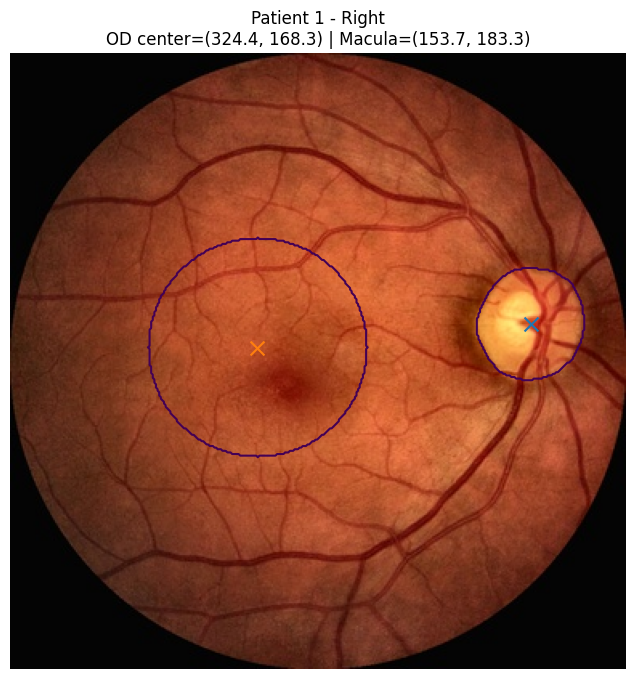


Patient 1 - Left
OD path: D:\Projects\College\Rabcl\masks_output\1\Left_OD.png
OD mask shape: (384, 384)
OD pixels: 4096
OD center: (63.4375, 187.363525390625)
OD diameter: 72.2162666941128
Estimated macula center: (np.float64(243.978166735282), 202.363525390625)
Macula ROI radius: 72.2162666941128
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 16241


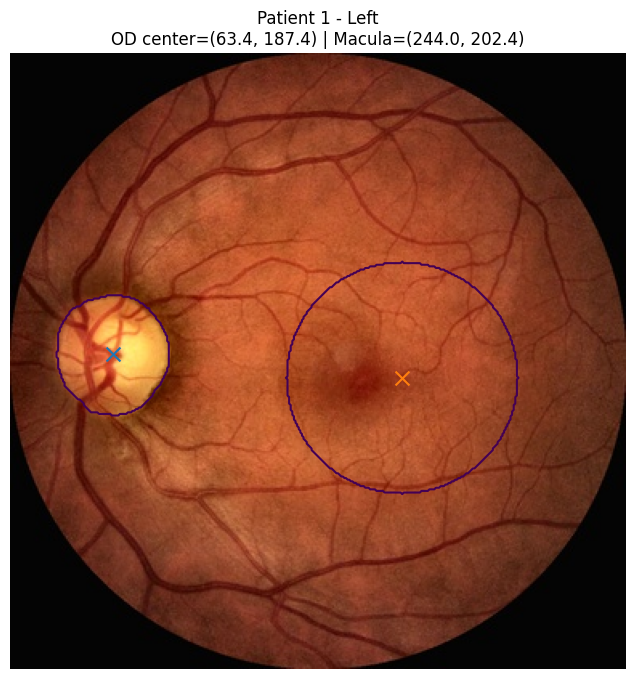


Patient 2 - Right
OD path: D:\Projects\College\Rabcl\masks_output\2\Right_OD.png
OD mask shape: (384, 384)
OD pixels: 3748
OD center: (327.58271077908216, 197.21691568836712)
OD diameter: 69.08040108212596
Estimated macula center: (np.float64(154.88170807376727), 212.21691568836712)
Macula ROI radius: 69.08040108212596
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 14949


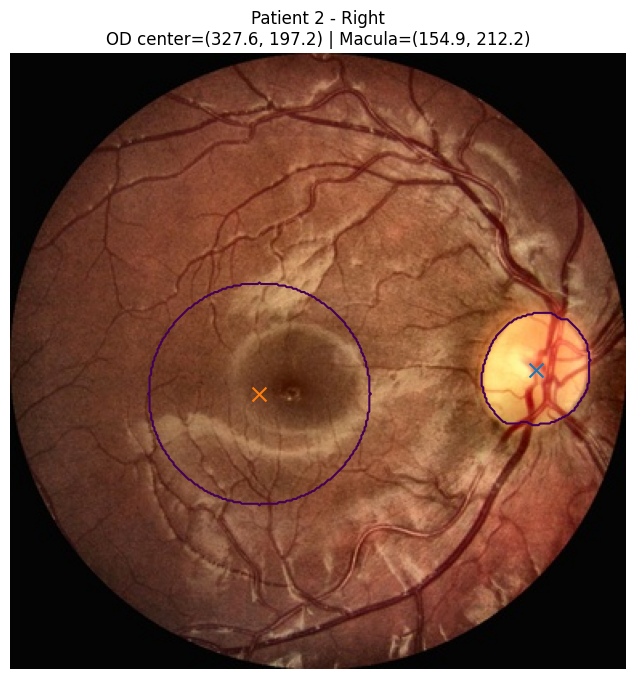


Patient 2 - Left
OD path: D:\Projects\College\Rabcl\masks_output\2\Left_OD.png
OD mask shape: (384, 384)
OD pixels: 3556
OD center: (74.93082114735658, 178.28290213723284)
OD diameter: 67.2877390100027
Estimated macula center: (np.float64(243.15016867236335), 193.28290213723284)
Macula ROI radius: 67.2877390100027
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 14073


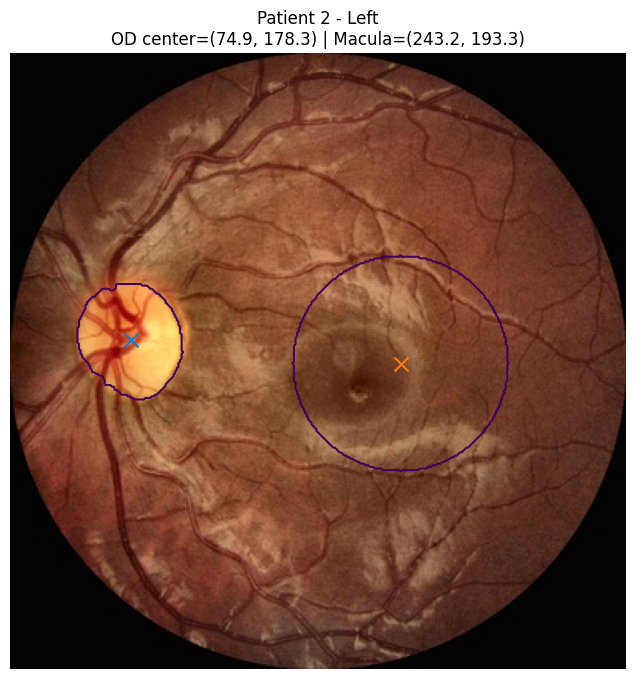


Patient 3 - Right
OD path: D:\Projects\College\Rabcl\masks_output\3\Right_OD.png
OD mask shape: (384, 384)
OD pixels: 3081
OD center: (314.2048036351834, 202.7864329763064)
OD diameter: 62.63266749332202
Estimated macula center: (np.float64(157.62313490187836), 217.7864329763064)
Macula ROI radius: 62.63266749332202
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 12453


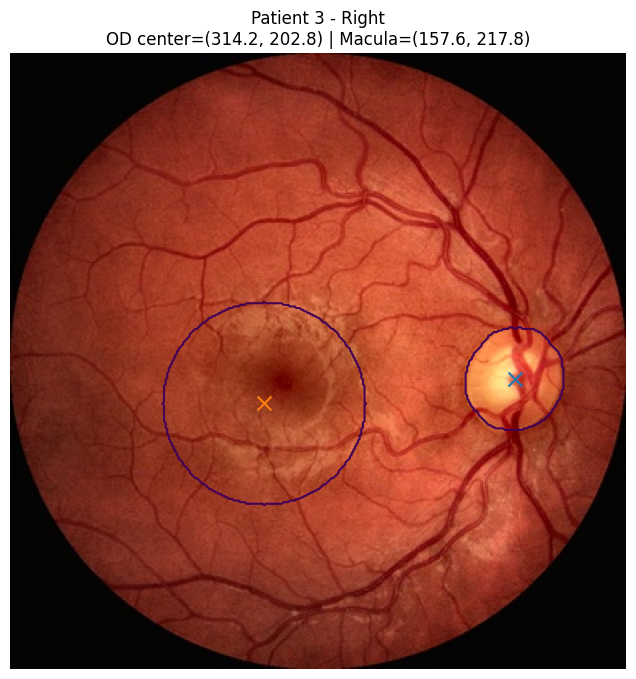


Patient 3 - Left
OD path: D:\Projects\College\Rabcl\masks_output\3\Left_OD.png
OD mask shape: (384, 384)
OD pixels: 2745
OD center: (73.9511839708561, 184.85865209471766)
OD diameter: 59.11888488713248
Estimated macula center: (np.float64(221.7483961886873), 199.85865209471766)
Macula ROI radius: 59.11888488713248
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 10913


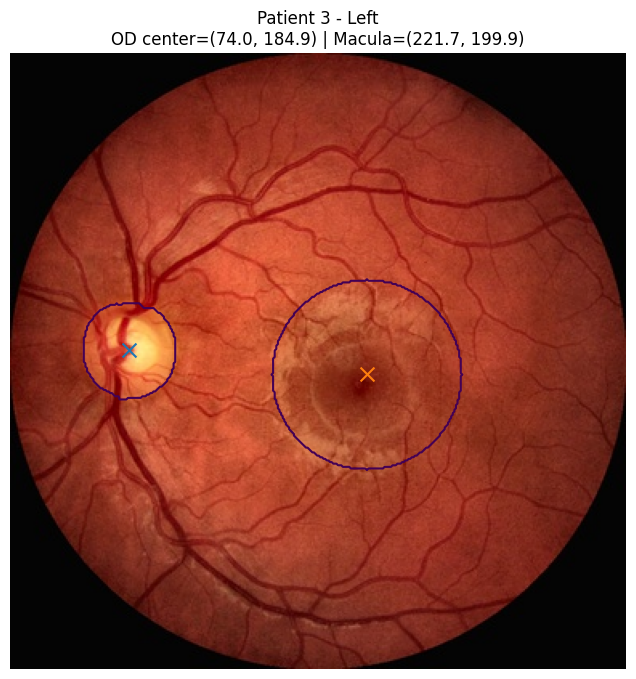


Patient 4 - Right
OD path: D:\Projects\College\Rabcl\masks_output\4\Right_OD.png
OD mask shape: (384, 384)
OD pixels: 3482
OD center: (335.4796094198736, 177.50717978173464)
OD diameter: 66.58393270728185
Estimated macula center: (np.float64(169.019777651669), 192.50717978173464)
Macula ROI radius: 66.58393270728185
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 14073


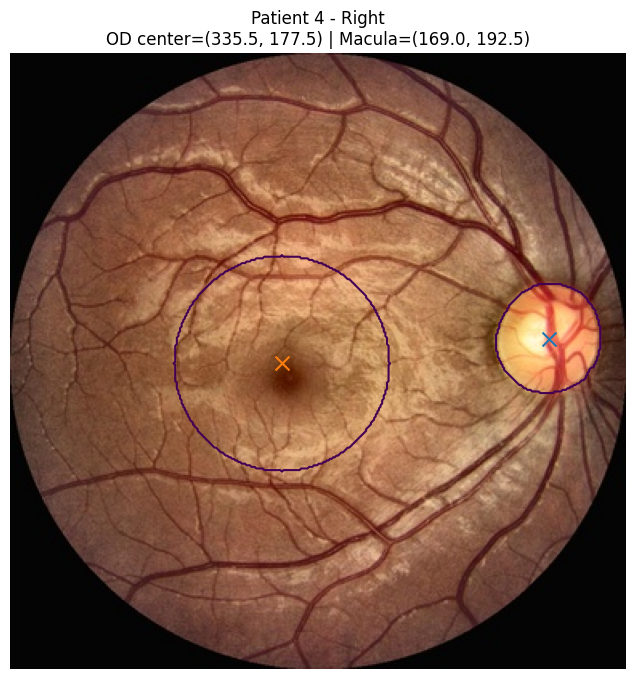


Patient 4 - Left
OD path: D:\Projects\College\Rabcl\masks_output\4\Left_OD.png
OD mask shape: (384, 384)
OD pixels: 3291
OD center: (57.01093892433911, 178.05499848070497)
OD diameter: 64.73199627482086
Estimated macula center: (np.float64(218.84092961139126), 193.05499848070497)
Macula ROI radius: 64.73199627482086
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 13273


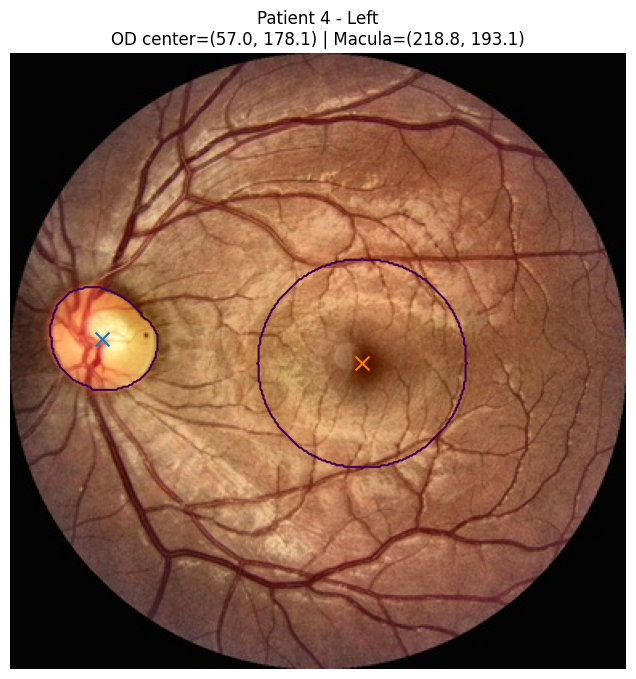


Patient 5 - Right
OD path: D:\Projects\College\Rabcl\masks_output\5\Right_OD.png
OD mask shape: (384, 384)
OD pixels: 3309
OD center: (344.5512239347235, 203.45995769114535)
OD diameter: 64.9087794795793
Estimated macula center: (np.float64(182.2792752357753), 218.45995769114535)
Macula ROI radius: 64.9087794795793
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 13273


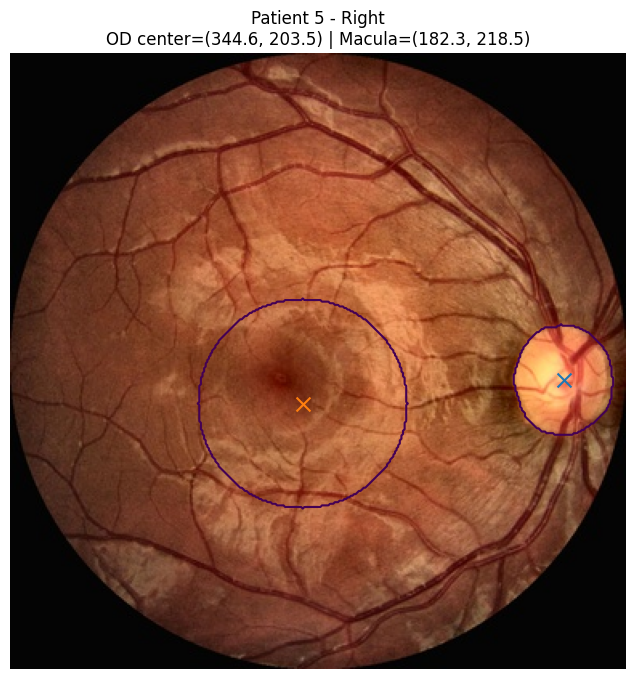


Patient 5 - Left
OD path: D:\Projects\College\Rabcl\masks_output\5\Left_OD.png
OD mask shape: (384, 384)
OD pixels: 3267
OD center: (47.13437404346495, 181.0719314355678)
OD diameter: 64.49553157118544
Estimated macula center: (np.float64(208.37320297142855), 196.0719314355678)
Macula ROI radius: 64.49553157118544
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 12853


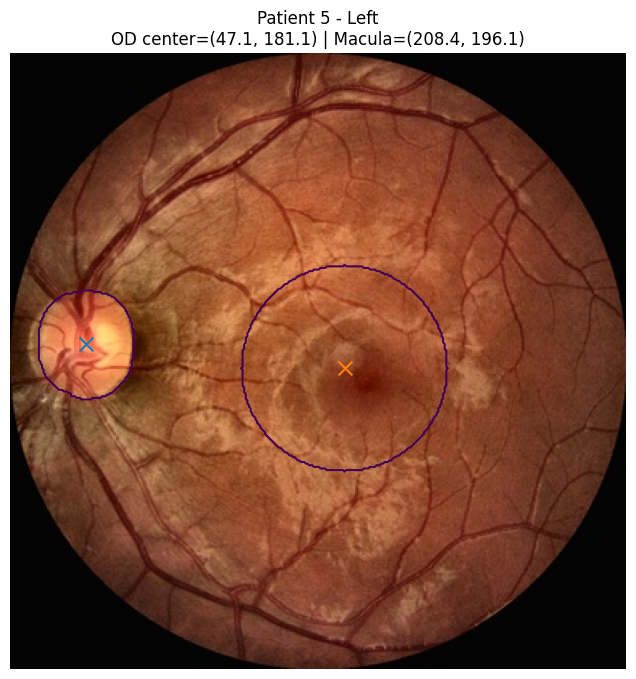

In [7]:
# ============================================================
# DEBUG OD MASK + MACULA GEOMETRY
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

test_manifest = manifest.head(10)


for _, row in test_manifest.iterrows():

    patient_id = int(row["patient_id"])

    eye = str(
        row["exam_eye"]
    ).strip().lower()

    if eye == "left":
        eye_name = "Left"
    elif eye == "right":
        eye_name = "Right"
    else:
        continue

    # --------------------------------------------------------
    # OD mask
    # --------------------------------------------------------

    od_path = os.path.join(
        MASKS_OUTPUT,
        str(patient_id),
        f"{eye_name}_OD.png"
    )

    od_mask = cv2.imread(
        od_path,
        cv2.IMREAD_GRAYSCALE
    )

    print("\n" + "=" * 60)
    print(
        f"Patient {patient_id} - {eye_name}"
    )
    print(
        "OD path:",
        od_path
    )

    if od_mask is None:

        print("❌ OD mask could not be loaded")
        continue

    print(
        "OD mask shape:",
        od_mask.shape
    )

    print(
        "OD pixels:",
        np.sum(od_mask > 0)
    )

    # --------------------------------------------------------
    # Find OD geometry
    # --------------------------------------------------------

    geometry = get_od_geometry(
        od_mask
    )

    if geometry is None:

        print(
            "❌ OD mask is empty"
        )

        continue

    disc_x, disc_y, disc_diameter = geometry

    print(
        "OD center:",
        (disc_x, disc_y)
    )

    print(
        "OD diameter:",
        disc_diameter
    )

    # --------------------------------------------------------
    # Calculate macula position
    # --------------------------------------------------------

    distance = (
        MACULA_DISTANCE_OD_DIAMETERS
        * disc_diameter
    )

    if eye == "left":

        macula_x = disc_x + distance

    else:

        macula_x = disc_x - distance

    MACULA_Y_OFFSET = 15

    macula_y = disc_y + MACULA_Y_OFFSET

    roi_radius = (
        MACULA_RADIUS_OD_DIAMETERS
        * disc_diameter
    )

    print(
        "Estimated macula center:",
        (macula_x, macula_y)
    )

    print(
        "Macula ROI radius:",
        roi_radius
    )

    # --------------------------------------------------------
    # Check whether center is inside image
    # --------------------------------------------------------

    h, w = od_mask.shape

    print(
        "Image size:",
        (w, h)
    )

    print(
        "Macula center inside image:",
        0 <= macula_x < w
        and
        0 <= macula_y < h
    )

    # --------------------------------------------------------
    # Create test mask
    # --------------------------------------------------------

    test_mask = np.zeros_like(
        od_mask,
        dtype=np.uint8
    )

    cv2.circle(
        test_mask,
        (
            int(round(macula_x)),
            int(round(macula_y))
        ),
        int(round(roi_radius)),
        255,
        -1
    )

    print(
        "Generated macula pixels:",
        np.sum(test_mask > 0)
    )

    # --------------------------------------------------------
    # Visualize
    # --------------------------------------------------------

    image_path = os.path.join(
        r"D:\Projects\College\Rabcl\BRSET_processed\train",
        str(patient_id),
        eye + ".jpg"
    )

    image = cv2.imread(
        image_path
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(
        figsize=(8, 8)
    )

    plt.imshow(image)

    # OD contour
    contours, _ = cv2.findContours(
        od_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    plt.contour(
        od_mask > 0,
        levels=[0.5]
    )

    # Macula ROI
    plt.contour(
        test_mask > 0,
        levels=[0.5]
    )

    plt.scatter(
        disc_x,
        disc_y,
        marker="x",
        s=100
    )

    plt.scatter(
        macula_x,
        macula_y,
        marker="x",
        s=100
    )

    plt.title(
        f"Patient {patient_id} - {eye_name}\n"
        f"OD center=({disc_x:.1f}, {disc_y:.1f}) | "
        f"Macula=({macula_x:.1f}, {macula_y:.1f})"
    )

    plt.axis("off")
    plt.show()


Patient 197 - Right
OD path: D:\Projects\College\Rabcl\masks_output\197\Right_OD.png
OD mask shape: (384, 384)
OD pixels: 3361
OD center: (342.4489735197858, 191.97113954180304)
OD diameter: 65.41680296265541
Estimated macula center: (np.float64(178.90696611314726), 191.97113954180304)
Macula ROI radius: 65.41680296265541
Image size: (384, 384)
Macula center inside image: True
Generated macula pixels: 13273
Image path: D:\Projects\College\Rabcl\BRSET_processed\train\197\right.jpg
Image shape: (384, 384, 3)


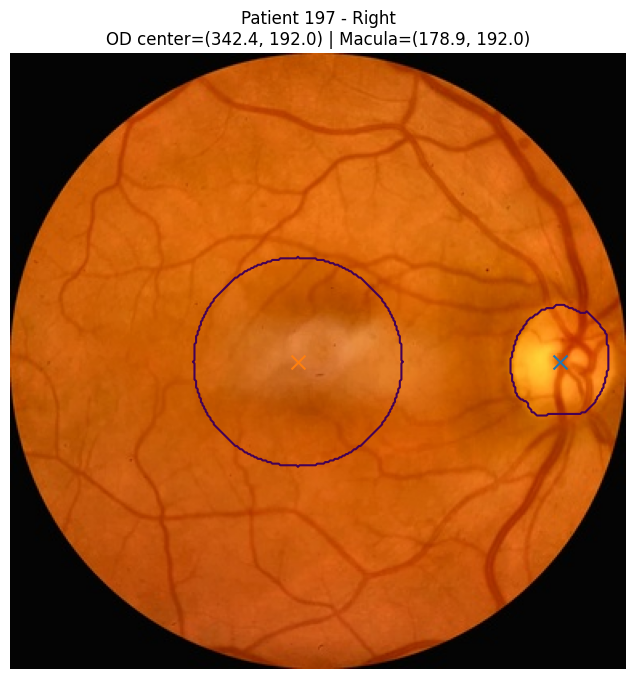

In [4]:
# ============================================================
# DEBUG OD MASK + MACULA GEOMETRY
# Patient 197 - Right eye only
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

BRSET_DIR = (
    r"D:\Projects\College\Rabcl\BRSET_processed\train"
)


# ============================================================
# PATIENT / EYE
# ============================================================

patient_id = 197
eye = "right"
eye_name = "Right"


# ============================================================
# OD MASK
# ============================================================

od_path = os.path.join(
    MASKS_OUTPUT,
    str(patient_id),
    f"{eye_name}_OD.png"
)

od_mask = cv2.imread(
    od_path,
    cv2.IMREAD_GRAYSCALE
)


print("\n" + "=" * 60)
print(f"Patient {patient_id} - {eye_name}")
print("=" * 60)

print(
    "OD path:",
    od_path
)


if od_mask is None:

    print("❌ OD mask could not be loaded")

else:

    print(
        "OD mask shape:",
        od_mask.shape
    )

    print(
        "OD pixels:",
        np.sum(od_mask > 0)
    )


    # ========================================================
    # FIND OD GEOMETRY
    # ========================================================

    geometry = get_od_geometry(
        od_mask
    )


    if geometry is None:

        print(
            "❌ OD mask is empty"
        )

    else:

        disc_x, disc_y, disc_diameter = geometry


        print(
            "OD center:",
            (disc_x, disc_y)
        )

        print(
            "OD diameter:",
            disc_diameter
        )


        # ====================================================
        # CALCULATE MACULA POSITION
        # ====================================================

        distance = (
            MACULA_DISTANCE_OD_DIAMETERS
            * disc_diameter
        )


        # Right eye → macula is to the LEFT of OD
        macula_x = disc_x - distance

        macula_y = disc_y


        roi_radius = (
            MACULA_RADIUS_OD_DIAMETERS
            * disc_diameter
        )


        print(
            "Estimated macula center:",
            (macula_x, macula_y)
        )

        print(
            "Macula ROI radius:",
            roi_radius
        )


        # ====================================================
        # CHECK IMAGE BOUNDARIES
        # ====================================================

        h, w = od_mask.shape

        print(
            "Image size:",
            (w, h)
        )

        print(
            "Macula center inside image:",
            0 <= macula_x < w
            and
            0 <= macula_y < h
        )


        # ====================================================
        # CREATE MACULA TEST MASK
        # ====================================================

        test_mask = np.zeros_like(
            od_mask,
            dtype=np.uint8
        )


        cv2.circle(
            test_mask,
            (
                int(round(macula_x)),
                int(round(macula_y))
            ),
            int(round(roi_radius)),
            255,
            -1
        )


        print(
            "Generated macula pixels:",
            np.sum(test_mask > 0)
        )


        # ====================================================
        # LOAD ORIGINAL IMAGE
        # ====================================================

        image_path = os.path.join(
            BRSET_DIR,
            str(patient_id),
            "right.jpg"
        )


        image = cv2.imread(
            image_path
        )


        if image is None:

            print(
                "❌ Could not load image:",
                image_path
            )

        else:

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )


            print(
                "Image path:",
                image_path
            )

            print(
                "Image shape:",
                image.shape
            )


            # =================================================
            # VISUALIZE
            # =================================================

            plt.figure(
                figsize=(8, 8)
            )


            plt.imshow(
                image
            )


            # -------------------------------------------------
            # OD contour
            # -------------------------------------------------

            plt.contour(
                od_mask > 0,
                levels=[0.5]
            )


            # -------------------------------------------------
            # Macula ROI
            # -------------------------------------------------

            plt.contour(
                test_mask > 0,
                levels=[0.5]
            )


            # -------------------------------------------------
            # OD center
            # -------------------------------------------------

            plt.scatter(
                disc_x,
                disc_y,
                marker="x",
                s=100
            )


            # -------------------------------------------------
            # Macula center
            # -------------------------------------------------

            plt.scatter(
                macula_x,
                macula_y,
                marker="x",
                s=100
            )


            plt.title(
                f"Patient {patient_id} - Right\n"
                f"OD center=({disc_x:.1f}, {disc_y:.1f}) | "
                f"Macula=({macula_x:.1f}, {macula_y:.1f})"
            )


            plt.axis(
                "off"
            )

            plt.show()

In [94]:
import os

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

removed = 0

for patient_id in os.listdir(MASKS_OUTPUT):

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        patient_id
    )

    if not os.path.isdir(patient_folder):
        continue

    for eye_name in ["Left", "Right"]:

        macula_path = os.path.join(
            patient_folder,
            f"{eye_name}_macula.png"
        )

        if os.path.isfile(macula_path):

            os.remove(macula_path)

            print(
                f"Removed: {macula_path}"
            )

            removed += 1

print()
print("Existing macula masks removed:", removed)


Existing macula masks removed: 0


In [97]:
# ============================================================
# GENERATE MACULA ROI MASKS FROM OD GEOMETRY
# ============================================================

import os
import cv2
import numpy as np

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

invalid_macula_patients = set()

# ------------------------------------------------------------
# TESTING
# ------------------------------------------------------------
# Keep head(10) for testing.
# Change to manifest for the complete dataset.
test_manifest = manifest.head(10)


# ============================================================
# PROCESS IMAGES
# ============================================================

success = 0
skipped = 0
failed = 0

for _, row in manifest.iterrows():

    patient_id = int(row["patient_id"])

    eye = str(
        row["exam_eye"]
    ).strip().lower()

    # --------------------------------------------------------
    # Determine eye name
    # --------------------------------------------------------

    if eye == "left":

        eye_name = "Left"

    elif eye == "right":

        eye_name = "Right"

    else:

        print(
            f"Unknown eye: {row['exam_eye']}"
        )

        failed += 1
        continue


    # ========================================================
    # PATIENT OUTPUT FOLDER
    # ========================================================

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        str(patient_id)
    )

    os.makedirs(
        patient_folder,
        exist_ok=True
    )


    # ========================================================
    # OD MASK
    # ========================================================

    od_path = os.path.join(
        MASKS_OUTPUT,
        str(patient_id),
        f"{eye_name}_OD.png"
    )

    od_mask = cv2.imread(
        od_path,
        cv2.IMREAD_GRAYSCALE
    )


    if od_mask is None:

        print(
            f"❌ OD mask could not be loaded: "
            f"patient {patient_id}, {eye_name}"
        )

        failed += 1
        continue


    # ========================================================
    # FIND OD GEOMETRY
    # ========================================================

    geometry = get_od_geometry(
        od_mask
    )


    if geometry is None:

        print(
            f"❌ OD mask is empty: "
            f"patient {patient_id}, {eye_name}"
        )

        failed += 1
        continue


    disc_x, disc_y, disc_diameter = geometry


    # ========================================================
    # CALCULATE MACULA POSITION
    # ========================================================

    distance = (
        MACULA_DISTANCE_OD_DIAMETERS
        * disc_diameter
    )


    if eye == "left":

        macula_x = disc_x + distance

    else:

        macula_x = disc_x - distance


    # --------------------------------------------------------
    # Move ROI downward
    # --------------------------------------------------------

    MACULA_Y_OFFSET = 15

    macula_y = (
        disc_y
        + MACULA_Y_OFFSET
    )


    # ========================================================
    # MACULA ROI RADIUS
    # ========================================================

    roi_radius = (
        MACULA_RADIUS_OD_DIAMETERS
        * disc_diameter
    )


    # ========================================================
    # CHECK WHETHER MACULA CENTER IS INSIDE IMAGE
    # ========================================================

    h, w = od_mask.shape

    if not (
        0 <= macula_x < w
        and
        0 <= macula_y < h
    ):
        print(
            f"❌ Macula center outside image: "
            f"patient {patient_id}, {eye_name}"
        )

        invalid_macula_patients.add(
            patient_id
        )

        failed += 1
        continue


    # ========================================================
    # CREATE MACULA ROI MASK
    # ========================================================

    test_mask = np.zeros_like(
        od_mask,
        dtype=np.uint8
    )


    cv2.circle(
        test_mask,
        (
            int(round(macula_x)),
            int(round(macula_y))
        ),
        int(round(roi_radius)),
        255,
        -1
    )


    # ========================================================
    # OUTPUT PATH
    # ========================================================

    output_path = os.path.join(
        patient_folder,
        f"{eye_name}_macula.png"
    )


    # ========================================================
    # SKIP IF ALREADY EXISTS
    # ========================================================

    if os.path.isfile(output_path):

        skipped += 1
        continue


    # ========================================================
    # SAVE MACULA MASK
    # ========================================================

    success_write = cv2.imwrite(
        output_path,
        test_mask
    )


    if not success_write:

        print(
            f"❌ Could not save: "
            f"{output_path}"
        )

        failed += 1
        continue


    # print(
    #     f"✅ Saved: {output_path}"
    # )

    success += 1


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("MACULA ROI MASK GENERATION COMPLETE")
print("=" * 60)

print(
    "New masks generated:",
    success
)

print(
    "Already existed:",
    skipped
)

print(
    "Failed:",
    failed
)

print(
    "Total rows processed:",
    len(test_manifest)
)

print()
print(
    "Output folder:",
    MASKS_OUTPUT
)

❌ Macula center outside image: patient 367, Left
❌ Macula center outside image: patient 400, Right
❌ Macula center outside image: patient 400, Left
❌ Macula center outside image: patient 413, Left
❌ Macula center outside image: patient 447, Right
❌ Macula center outside image: patient 447, Left
❌ Macula center outside image: patient 671, Left
❌ Macula center outside image: patient 755, Left
❌ Macula center outside image: patient 778, Right
❌ Macula center outside image: patient 778, Left
❌ Macula center outside image: patient 805, Right
❌ Macula center outside image: patient 805, Left
❌ Macula center outside image: patient 913, Right
❌ Macula center outside image: patient 913, Left
❌ Macula center outside image: patient 946, Left
❌ Macula center outside image: patient 1152, Right
❌ Macula center outside image: patient 1152, Left
❌ Macula center outside image: patient 1171, Left
❌ Macula center outside image: patient 1171, Right
❌ Macula center outside image: patient 1367, Left
❌ Macula

In [98]:
# ============================================================
# REMOVE PATIENTS WITH INVALID MACULA ROI
# ============================================================

print()
print("=" * 60)
print("REMOVING INVALID MACULA PATIENTS")
print("=" * 60)

print(
    "Patients with macula outside image:",
    len(invalid_macula_patients)
)

print(
    "Patient IDs:",
    sorted(invalid_macula_patients)
)


REMOVING INVALID MACULA PATIENTS
Patients with macula outside image: 56
Patient IDs: [367, 400, 413, 447, 671, 755, 778, 805, 913, 946, 1152, 1171, 1367, 1589, 1908, 1969, 2099, 2318, 2379, 2620, 2661, 2716, 3135, 3204, 3469, 3484, 3493, 3708, 4316, 4555, 4590, 4659, 4736, 4913, 5243, 5390, 5576, 5673, 6106, 6577, 6620, 6725, 6741, 6818, 6863, 7110, 7152, 7581, 7610, 7638, 7670, 7699, 7877, 7946, 7949, 8055]


In [99]:
import shutil

BACKUP_PATH = (
    r"D:\Projects\College\Rabcl\preprocessed_before_macula_cleanup.csv"
)

shutil.copy2(
    MANIFEST_PATH,
    BACKUP_PATH
)

print(
    "CSV backup created:",
    BACKUP_PATH
)

CSV backup created: D:\Projects\College\Rabcl\preprocessed_before_macula_cleanup.csv


In [105]:
# ============================================================
# REMOVE INVALID MACULA PATIENTS FROM CSV
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

manifest["patient_id"] = (
    manifest["patient_id"].astype(int)
)

print(
    "Rows before:",
    len(manifest)
)

print(
    "Patients before:",
    manifest["patient_id"].nunique()
)

manifest_clean = manifest[
    ~manifest["patient_id"].isin(
        invalid_macula_patients
    )
].copy()

print(
    "Rows after:",
    len(manifest_clean)
)

print(
    "Patients after:",
    manifest_clean["patient_id"].nunique()
)

print(
    "Patients removed:",
    len(invalid_macula_patients)
)

Rows before: 11300
Patients before: 5650
Rows after: 11188
Patients after: 5594
Patients removed: 56


In [110]:
manifest_clean.to_csv(
    MANIFEST_PATH,
    index=False
)

print(
    "✅ preprocessed.csv updated."
)

✅ preprocessed.csv updated.


In [111]:
# ============================================================
# REMOVE INVALID PATIENT FOLDERS
# ============================================================

import os
import shutil

removed = 0
not_found = 0

for patient_id in sorted(
    invalid_macula_patients
):

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        str(patient_id)
    )

    if os.path.isdir(patient_folder):

        shutil.rmtree(
            patient_folder
        )

        removed += 1

    else:

        not_found += 1

print()
print("=" * 60)
print("MASK FOLDER CLEANUP COMPLETE")
print("=" * 60)

print(
    "Patient folders removed:",
    removed
)

print(
    "Patient folders not found:",
    not_found
)


MASK FOLDER CLEANUP COMPLETE
Patient folders removed: 0
Patient folders not found: 56


In [112]:
# ============================================================
# FINAL MASK COMPLETENESS CHECK
# ============================================================

import os

MASKS_OUTPUT = r"D:\Projects\College\Rabcl\masks_output"

required_files = [
    "Left_OD.png",
    "Right_OD.png",
    "Left_vessel.png",
    "Right_vessel.png",
    "Left_macula.png",
    "Right_macula.png"
]

total_patients = 0
complete_patients = 0
incomplete_patients = []

for patient_id in sorted(os.listdir(MASKS_OUTPUT)):

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        patient_id
    )

    # Ignore files that may be directly inside masks_output
    if not os.path.isdir(patient_folder):
        continue

    total_patients += 1

    missing_files = []

    for filename in required_files:

        file_path = os.path.join(
            patient_folder,
            filename
        )

        if not os.path.isfile(file_path):
            missing_files.append(filename)

    if len(missing_files) == 0:

        complete_patients += 1

    else:

        incomplete_patients.append({
            "patient_id": patient_id,
            "missing": missing_files
        })


# ============================================================
# SUMMARY
# ============================================================

print()
print("=" * 70)
print("FINAL MASK COMPLETENESS CHECK")
print("=" * 70)

print(
    "Total patient folders:",
    total_patients
)

print(
    "Complete patients:",
    complete_patients
)

print(
    "Incomplete patients:",
    len(incomplete_patients)
)


# ============================================================
# SHOW INCOMPLETE PATIENTS
# ============================================================

if incomplete_patients:

    print()
    print("Patients with missing masks:")
    print()

    for item in incomplete_patients:

        print(
            f"Patient {item['patient_id']}: "
            f"Missing {item['missing']}"
        )

else:

    print()
    print("✅ ALL PATIENTS HAVE ALL 6 MASKS")


FINAL MASK COMPLETENESS CHECK
Total patient folders: 5594
Complete patients: 5594
Incomplete patients: 0

✅ ALL PATIENTS HAVE ALL 6 MASKS


In [114]:
import os

# Use the current CSV loaded in the notebook
manifest = pd.read_csv("D:\Projects\College\Rabcl\preprocessed.csv")
csv_patient_ids = sorted(manifest["patient_id"].astype(int).unique())

mask_dirs = [
    d for d in os.listdir(MASKS_OUTPUT)
    if os.path.isdir(os.path.join(MASKS_OUTPUT, d))
]

mask_patient_ids = sorted(int(d) for d in mask_dirs)

missing_in_masks = sorted(set(csv_patient_ids) - set(mask_patient_ids))
extra_in_masks = sorted(set(mask_patient_ids) - set(csv_patient_ids))

missing_patient_dirs = []
missing_eye_files = []

for pid in csv_patient_ids:
    folder = os.path.join(MASKS_OUTPUT, str(pid))
    if not os.path.isdir(folder):
        missing_patient_dirs.append(pid)
        continue

    for eye in ["Left", "Right"]:
        required_files = [
            f"{eye}_OD.png",
            f"{eye}_macula.png",
        ]
        for fname in required_files:
            path = os.path.join(folder, fname)
            if not os.path.isfile(path):
                missing_eye_files.append((pid, eye, fname))

print("CSV patient count:", len(csv_patient_ids))
print("Masks folder patient count:", len(mask_patient_ids))
print("Patients missing from masks_output:", missing_in_masks[:20], " ... total:", len(missing_in_masks))
print("Patients in masks_output but not in CSV:", extra_in_masks[:20], " ... total:", len(extra_in_masks))
print("Missing patient folders:", missing_patient_dirs[:20], " ... total:", len(missing_patient_dirs))
print("Missing eye files:", missing_eye_files[:20], " ... total:", len(missing_eye_files))

# Optional: raise if any mismatch is found
if missing_in_masks or extra_in_masks or missing_patient_dirs or missing_eye_files:
    print("WARNING: cross-check failed for one or more patient IDs/files.")
else:
    print("OK: all patient IDs and required mask files are present in masks_output.")

CSV patient count: 5594
Masks folder patient count: 5594
Patients missing from masks_output: []  ... total: 0
Patients in masks_output but not in CSV: []  ... total: 0
Missing patient folders: []  ... total: 0
Missing eye files: []  ... total: 0
OK: all patient IDs and required mask files are present in masks_output.
